# 04 - Hyperparameter Tuning and Threshold Optimization

## 1. Setup

The defaults below tune all four baseline model families. If the run is too slow, reduce `N_ITER_PER_MODEL` or tune only `CatBoost` and `XGBoost` first.

In [1]:
from pathlib import Path
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
CV_FOLDS = 3
N_ITER_PER_MODEL = 12
VALIDATION_SIZE = 0.20
MIN_RECALL_TARGET = 0.80

TUNE_MODELS = [
    'CatBoost',
    'XGBoost',
    'Logistic Regression',
    'Random Forest',
]

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH = PROJECT_ROOT / 'reports'
MODELS_PATH = PROJECT_ROOT / 'models'
PLOTS_PATH = PROJECT_ROOT / 'plots'

REPORTS_PATH.mkdir(exist_ok=True)
MODELS_PATH.mkdir(exist_ok=True)
PLOTS_PATH.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Tuning models: {TUNE_MODELS}')

Project root: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml
Tuning models: ['CatBoost', 'XGBoost', 'Logistic Regression', 'Random Forest']


## 2. Load Project Insights

These summaries drive the tuning plan: class imbalance is extreme, preprocessing has already handled skewness and scaling, and CatBoost is the strongest baseline by ROC-AUC.

In [2]:
summary_files = [
    REPORTS_PATH / 'eda_summary.txt',
    REPORTS_PATH / 'preprocessing_summary.txt',
    REPORTS_PATH / 'training_summary.txt',
]

for summary_file in summary_files:
    if summary_file.exists():
        text = summary_file.read_text(encoding='utf-8', errors='replace')
        display(Markdown(f'### {summary_file.name}'))
        print(text[:2500])
        if len(text) > 2500:
            print('\n... summary truncated for display ...')
    else:
        print(f'Missing summary: {summary_file}')

baseline_path = REPORTS_PATH / 'baseline_model_comparison.csv'
baseline_df = pd.read_csv(baseline_path) if baseline_path.exists() else pd.DataFrame()

display(Markdown('### Baseline Model Comparison'))
display(baseline_df)

### eda_summary.txt


EXPLORATORY DATA ANALYSIS - KEY INSIGHTS

1. DATASET OVERVIEW
   - Total transactions: 284,807
   - Features: 31
   - Data types: All numeric (suitable for ML)
   - Missing values: None detected ✓
   - Duplicates: 1081 rows

2. CLASS IMBALANCE (CRITICAL)
   - Normal transactions: 284,315 (99.827%)
   - Fraudulent transactions: 492 (0.173%)
   - Imbalance ratio: 1:577
       HIGHLY IMBALANCED - Standard accuracy metrics will be misleading
   ✓ Must use class weights or SMOTE in training phase
   ✓ Must prioritize Recall and ROC-AUC over accuracy

3. FEATURE CHARACTERISTICS
   - 28 features (V1-V28): PCA-transformed components
   - 1 feature: Time (seconds since first transaction)
   - 1 feature: Amount (transaction amount in dollars)
   - All features already scaled (except Amount/Time)

4. CORRELATION WITH FRAUD
   Most positively correlated with fraud:
Feature  Correlation
    V11     0.154876
     V4     0.133447
     V2     0.091289

   Most negatively correlated with fraud:
Featur

### preprocessing_summary.txt


DATA PREPROCESSING SUMMARY REPORT

1. DATA CLEANING
   - Duplicates removed: 1,081
   - Missing values: 0
   - Final raw shape: (283726, 31)

2. FEATURE ENGINEERING (Skewness Transformation)
   - Highly skewed features identified: 16
   - Transformation applied: log(1 + x) to ALL skewed features
   - Features transformed: V6, V20, V21, V5, V8 ... (16 total)
   
   Skewness before/after transformation:
   - V6: -1.0576 → -0.0260
   - V20: -1.3163 → -0.0366
   - V21: -1.3255 → 0.0828
   - V5: -1.6126 → 0.0929
   - V8: -1.6390 → 0.1473
   - V10: -1.6427 → 0.1269
   - V1: -1.6604 → -0.4115
   - V17: -1.6705 → 0.0564
   - V2: -1.8317 → 0.1450
   - V7: -1.8628 → 0.2634

   - Total features after transformation: 30

3. TRAIN-TEST SPLIT (STRATIFIED)
   - Training set: 226,980 samples
   - Test set: 56,746 samples
   - Split ratio: 80.0% / 20.0%

4. CLASS DISTRIBUTION
   Training set:
   - Normal: 226,602 (99.83%)
   - Fraud: 378 (0.17%)
   - Imbalance ratio: 1:599

   Test set:
   - Normal: 5

### training_summary.txt


MODEL TRAINING SUMMARY REPORT

1. TRAINING DATA
   - Training set size: 226,980 samples
   - Test set size: 56,746 samples
   - Features: 30
   - Fraud ratio (train): 0.0017 (378 fraud cases)
   - Fraud ratio (test): 0.0017 (95 fraud cases)

2. IMBALANCE HANDLING STRATEGY
   - Method: Class weights / Scale Pos Weight (built-in to models)
   - Logistic Regression: class_weight='balanced'
   - Random Forest: class_weight='balanced'
   - XGBoost: scale_pos_weight=599.48
   - CatBoost: scale_pos_weight=599.48

3. MODEL 1: LOGISTIC REGRESSION (BASELINE)
   Training time: 3.61 seconds
   
   Test Set Metrics:
   - Precision: 0.0296
   - Recall: 0.8737
   - F1-Score: 0.0572
   - ROC-AUC: 0.9610
   
   Overfitting Analysis:
   - Train ROC-AUC: 0.9801
   - Test ROC-AUC: 0.9610
   - Gap: 0.0191 (acceptable)

4. MODEL 2: RANDOM FOREST
   Training time: 35.37 seconds
   Parameters: n_estimators=100, max_depth=15, min_samples_split=5
   
   Test Set Metrics:
   - Precision: 0.8933
   - Recall: 0.7

### Baseline Model Comparison

,Model,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,CatBoost,0.534722,0.810526,0.644351,0.974106,6.258852
1,XGBoost,0.194103,0.831579,0.314741,0.961061,22.356417
2,Logistic Regression,0.029558,0.873684,0.057182,0.961020,3.611747
3,Random Forest,0.893333,0.705263,0.788235,0.954373,35.370847


## 3. Load Preprocessed Data

The notebook uses the scaled files created by `02_preprocessing.ipynb`. This keeps the exact train/test split and prevents fitting transformations on the test set.

In [3]:
required_files = {
    'X_train': DATA_PATH / 'X_train_scaled.csv',
    'X_test': DATA_PATH / 'X_test_scaled.csv',
    'y_train': DATA_PATH / 'y_train.csv',
    'y_test': DATA_PATH / 'y_test.csv',
}

missing_files = [str(path.relative_to(PROJECT_ROOT)) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        'Missing preprocessed data files. Run notebooks/02_preprocessing.ipynb first: '
        + ', '.join(missing_files)
    )

X_train = pd.read_csv(required_files['X_train'])
X_test = pd.read_csv(required_files['X_test'])
y_train = pd.read_csv(required_files['y_train']).squeeze('columns').astype(int)
y_test = pd.read_csv(required_files['y_test']).squeeze('columns').astype(int)

normal_count = int((y_train == 0).sum())
fraud_count = int((y_train == 1).sum())
scale_pos_weight = normal_count / fraud_count

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train fraud cases: {fraud_count:,} / {len(y_train):,}')
print(f'y_test fraud cases:  {int(y_test.sum()):,} / {len(y_test):,}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

X_train: (226980, 30)
X_test:  (56746, 30)
y_train fraud cases: 378 / 226,980
y_test fraud cases:  95 / 56,746
scale_pos_weight: 599.48


## 4. Tuning Strategy From Insights

- Class imbalance is about 1 fraud case per 599 normal cases in training, so every tuned model keeps class weighting or `scale_pos_weight`.
- Accuracy is not used for model selection.
- Average precision is added because precision-recall behavior is more informative under extreme imbalance.
- CatBoost is tuned first because it had the best baseline ROC-AUC and a strong precision/recall balance.
- Logistic Regression is kept because it had the highest recall baseline, but it needs threshold control to reduce false positives.
- Random Forest is kept because it had the highest precision baseline, but it needs tuning to recover recall.
- The test set is used only once, after hyperparameters and thresholds are chosen.

In [4]:
best_baseline = baseline_df.iloc[0]['Model'] if not baseline_df.empty else 'Unknown'

strategy = {
    'best_baseline_model': best_baseline,
    'primary_search_score': 'average_precision',
    'secondary_scores': ['roc_auc', 'recall', 'f1', 'precision'],
    'threshold_metric': f'F2 score with recall >= {MIN_RECALL_TARGET:.2f}',
    'imbalance_strategy': 'class_weight or scale_pos_weight',
    'data_leakage_rule': 'CV and threshold tuning use training data only; test is final only',
}

for key, value in strategy.items():
    print(f'{key}: {value}')

best_baseline_model: CatBoost
primary_search_score: average_precision
secondary_scores: ['roc_auc', 'recall', 'f1', 'precision']
threshold_metric: F2 score with recall >= 0.80
imbalance_strategy: class_weight or scale_pos_weight
data_leakage_rule: CV and threshold tuning use training data only; test is final only


## 5. Internal Validation Split

Randomized CV selects hyperparameters on `X_search`. A separate validation slice from the original training set chooses the classification threshold. The held-out test set remains untouched.

In [5]:
X_search, X_valid, y_search, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f'Search set:     {X_search.shape}, fraud ratio={y_search.mean():.5f}')
print(f'Validation set: {X_valid.shape}, fraud ratio={y_valid.mean():.5f}')
print(f'Test set:       {X_test.shape}, fraud ratio={y_test.mean():.5f}')

Search set:     (181584, 30), fraud ratio=0.00166
Validation set: (45396, 30), fraud ratio=0.00167
Test set:       (56746, 30), fraud ratio=0.00167


## 6. Evaluation Helpers

In [6]:
def predict_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min())
    raise TypeError('Model must expose predict_proba or decision_function.')


def metrics_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    beta = 2
    f2 = ((1 + beta**2) * precision * recall) / ((beta**2 * precision) + recall + 1e-12)
    return {
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F2': f2,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Average Precision': average_precision_score(y_true, y_proba),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
    }


def choose_threshold(y_true, y_proba, min_recall=MIN_RECALL_TARGET):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision = precision[:-1]
    recall = recall[:-1]
    beta = 2
    f2 = ((1 + beta**2) * precision * recall) / ((beta**2 * precision) + recall + 1e-12)

    valid = recall >= min_recall
    if valid.any():
        local_idx = np.argmax(f2[valid])
        idx = np.where(valid)[0][local_idx]
    else:
        idx = int(np.argmax(f2))

    threshold = float(thresholds[idx])
    return threshold, metrics_at_threshold(y_true, y_proba, threshold)


def safe_model_name(name):
    return name.lower().replace(' ', '_').replace('-', '_')

## 7. Model Search Spaces

The ranges are intentionally focused around the baseline behavior so the search stays practical. Increase `N_ITER_PER_MODEL` for a deeper pass.

In [7]:
scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
weight_candidates = [scale_pos_weight * 0.5, scale_pos_weight, scale_pos_weight * 1.5]

MODEL_CONFIGS = {
    'CatBoost': {
        'estimator': CatBoostClassifier(
            loss_function='Logloss', # logloss = - (y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
            eval_metric='AUC',   # AUC is a metric that measures the ability of a model to distinguish between classes. It ranges from 0 to 1, where 1 indicates perfect separation and 0.5 indicates random guessing.
            bootstrap_type='Bernoulli',
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
        'params': {
            'iterations': [200, 400, 700],
            'depth': [4, 5, 6, 7, 8],
            'learning_rate': [0.03, 0.05, 0.08, 0.10],
            'l2_leaf_reg': [1, 3, 5, 7, 9],
            'subsample': [0.70, 0.80, 0.90],
            'scale_pos_weight': weight_candidates,
        },
        'search_n_jobs': 1,
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            objective='binary:logistic',
            eval_metric='aucpr',
            tree_method='hist',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        ),
        'params': {
            'n_estimators': [200, 400, 700],
            'max_depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.03, 0.05, 0.10],
            'min_child_weight': [1, 3, 5, 7],
            'subsample': [0.70, 0.80, 0.90],
            'colsample_bytree': [0.70, 0.80, 0.90],
            'gamma': [0, 0.25, 0.50, 1.0],
            'reg_alpha': [0, 0.01, 0.10, 1.0],
            'reg_lambda': [1, 3, 5, 7],
            'scale_pos_weight': weight_candidates,
        },
        'search_n_jobs': 1,
    },
    'Logistic Regression': {
        'estimator': LogisticRegression(
            class_weight='balanced',
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'params': {
            'C': np.logspace(-3, 2, 12),
            'solver': ['lbfgs'],
            'penalty': ['l2'],  # L2 is a penalizing term that prevent overfitting by adding regulization term. and it's formula is 
        },
        'search_n_jobs': -1,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'params': {
            'n_estimators': [150, 250, 400],
            'max_depth': [8, 12, 16, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10],
            'max_features': ['sqrt', 'log2', 0.50],
            'class_weight': ['balanced', 'balanced_subsample'],
        },
        'search_n_jobs': 1,
    },
}

for model_name in TUNE_MODELS:
    if model_name not in MODEL_CONFIGS:
        raise ValueError(f'Unknown model in TUNE_MODELS: {model_name}')

## 8. Run Randomized Cross-Validation

The refit metric is average precision. This keeps the search sensitive to fraud ranking quality under extreme imbalance.

In [8]:
searches = {}
cv_rows = []

for model_name in TUNE_MODELS:
    config = MODEL_CONFIGS[model_name]
    print('\n' + '=' * 80)
    print(f'Tuning {model_name}')
    print('=' * 80)

    search = RandomizedSearchCV(
        estimator=config['estimator'],
        param_distributions=config['params'],
        n_iter=N_ITER_PER_MODEL,
        scoring=scoring,
        refit='average_precision',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=config['search_n_jobs'],
        verbose=2,
        return_train_score=True,
        error_score='raise',
    )

    start = time.time()
    search.fit(X_search, y_search)
    elapsed = time.time() - start

    searches[model_name] = search
    cv_result = pd.DataFrame(search.cv_results_)
    cv_result['Model'] = model_name
    cv_result['Search Time (s)'] = elapsed
    cv_rows.append(cv_result)

    print(f'Best average precision: {search.best_score_:.5f}')
    print(f'Best params: {search.best_params_}')
    print(f'Search time: {elapsed:.1f} seconds')

cv_results_df = pd.concat(cv_rows, ignore_index=True)
cv_results_df.to_csv(REPORTS_PATH / 'tuning_cv_results.csv', index=False)
print(f'CV results saved to {REPORTS_PATH / "tuning_cv_results.csv"}')


Tuning CatBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END depth=5, iterations=400, l2_leaf_reg=7, learning_rate=0.1, scale_pos_weight=599.4761904761905, subsample=0.9; total time=  14.7s
[CV] END depth=5, iterations=400, l2_leaf_reg=7, learning_rate=0.1, scale_pos_weight=599.4761904761905, subsample=0.9; total time=  12.0s
[CV] END depth=5, iterations=400, l2_leaf_reg=7, learning_rate=0.1, scale_pos_weight=599.4761904761905, subsample=0.9; total time=  12.3s
[CV] END depth=6, iterations=400, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=899.2142857142858, subsample=0.8; total time=  13.8s
[CV] END depth=6, iterations=400, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=899.2142857142858, subsample=0.8; total time=  12.9s
[CV] END depth=6, iterations=400, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=899.2142857142858, subsample=0.8; total time=  12.1s
[CV] END depth=6, iterations=200, l2_leaf_reg=3, learning_rate=0.05, scale_pos_weight=599.4761

## 9. Tune Thresholds and Evaluate Final Models

Thresholds are selected on the validation split using F2 score, with a recall floor. Final model performance is then measured once on the test set.

In [9]:
final_models = {}
final_results = []
threshold_results = []

for model_name, search in searches.items():
    print('\n' + '=' * 80)
    print(f'Final evaluation for {model_name}')
    print('=' * 80)

    validation_proba = predict_scores(search.best_estimator_, X_valid)
    best_threshold, validation_metrics = choose_threshold(
        y_valid,
        validation_proba,
        min_recall=MIN_RECALL_TARGET,
    )

    final_model = clone(search.best_estimator_)
    final_model.fit(X_train, y_train)
    final_models[model_name] = final_model

    train_proba = predict_scores(final_model, X_train)
    test_proba = predict_scores(final_model, X_test)
    default_metrics = metrics_at_threshold(y_test, test_proba, threshold=0.50)
    tuned_metrics = metrics_at_threshold(y_test, test_proba, threshold=best_threshold)

    train_auc = roc_auc_score(y_train, train_proba)
    overfit_gap = train_auc - tuned_metrics['ROC-AUC']

    model_path = MODELS_PATH / f'tuned_{safe_model_name(model_name)}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(final_model, f)

    final_results.append({
        'Model': model_name,
        'Best Params': search.best_params_,
        'CV Average Precision': search.best_score_,
        'Validation Threshold': best_threshold,
        'Validation Precision': validation_metrics['Precision'],
        'Validation Recall': validation_metrics['Recall'],
        'Validation F1': validation_metrics['F1'],
        'Validation F2': validation_metrics['F2'],
        'Test Precision @0.50': default_metrics['Precision'],
        'Test Recall @0.50': default_metrics['Recall'],
        'Test F1 @0.50': default_metrics['F1'],
        'Test Precision @Tuned': tuned_metrics['Precision'],
        'Test Recall @Tuned': tuned_metrics['Recall'],
        'Test F1 @Tuned': tuned_metrics['F1'],
        'Test F2 @Tuned': tuned_metrics['F2'],
        'Test ROC-AUC': tuned_metrics['ROC-AUC'],
        'Test Average Precision': tuned_metrics['Average Precision'],
        'Test FP @Tuned': tuned_metrics['FP'],
        'Test FN @Tuned': tuned_metrics['FN'],
        'Test TP @Tuned': tuned_metrics['TP'],
        'Train ROC-AUC': train_auc,
        'Overfit Gap': overfit_gap,
        'Saved Model': str(model_path.relative_to(PROJECT_ROOT)),
    })

    threshold_results.append({
        'Model': model_name,
        'Threshold': best_threshold,
        **{f'Validation {key}': value for key, value in validation_metrics.items()},
    })

    print(f'Validation threshold: {best_threshold:.5f}')
    print(f"Validation recall/F2: {validation_metrics['Recall']:.4f} / {validation_metrics['F2']:.4f}")
    print(f"Test tuned precision/recall/F1: {tuned_metrics['Precision']:.4f} / {tuned_metrics['Recall']:.4f} / {tuned_metrics['F1']:.4f}")
    print(f"Test ROC-AUC / AP: {tuned_metrics['ROC-AUC']:.4f} / {tuned_metrics['Average Precision']:.4f}")
    print(f'Model saved: {model_path}')

final_results_df = pd.DataFrame(final_results)
thresholds_df = pd.DataFrame(threshold_results)

final_results_df = final_results_df.sort_values(
    ['Validation F2', 'CV Average Precision', 'Test ROC-AUC'],
    ascending=False,
).reset_index(drop=True)

final_results_df.to_csv(REPORTS_PATH / 'tuning_results.csv', index=False)
thresholds_df.to_csv(REPORTS_PATH / 'tuned_thresholds.csv', index=False)

best_tuned_name = final_results_df.loc[0, 'Model']
best_tuned_model = final_models[best_tuned_name]
with open(MODELS_PATH / 'best_tuned_model.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

display(final_results_df)
print(f'Best tuned model by validation F2: {best_tuned_name}')
print(f'Results saved to {REPORTS_PATH / "tuning_results.csv"}')
print(f'Best model saved to {MODELS_PATH / "best_tuned_model.pkl"}')


Final evaluation for CatBoost
Validation threshold: 0.92933
Validation recall/F2: 0.8553 / 0.8690
Test tuned precision/recall/F1: 0.9733 / 0.7684 / 0.8588
Test ROC-AUC / AP: 0.9757 / 0.8138
Model saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\models\tuned_catboost.pkl

Final evaluation for XGBoost
Validation threshold: 0.89896
Validation recall/F2: 0.8553 / 0.8737
Test tuned precision/recall/F1: 0.9867 / 0.7789 / 0.8706
Test ROC-AUC / AP: 0.9683 / 0.8114
Model saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\models\tuned_xgboost.pkl

Final evaluation for Logistic Regression
Validation threshold: 0.90620
Validation recall/F2: 0.8026 / 0.5083
Test tuned precision/recall/F1: 0.2296 / 0.8000 / 0.3568
Test ROC-AUC / AP: 0.9615 / 0.5026
Model saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\models\tuned_logistic_regression.pkl

Final evaluation for Random Forest
Validation threshold: 0.36345
Validation recall/F2: 0.8553 / 0.8575
Test tuned precision/recall/F1

,Model,Best Params,CV Average Precision,Validation Threshold,Validation Precision,Validation Recall,Validation F1,Validation F2,Test Precision @0.50,Test Recall @0.50,...,Test F1 @Tuned,Test F2 @Tuned,Test ROC-AUC,Test Average Precision,Test FP @Tuned,Test FN @Tuned,Test TP @Tuned,Train ROC-AUC,Overfit Gap,Saved Model
0,XGBoost,"{'subsample': 0.7, 'scale_pos_weight': 899.214...",0.823776,0.898964,0.955882,0.855263,0.902778,0.873656,0.950000,0.800000,...,0.870588,0.813187,0.968261,0.811376,1,21,74,1.000000,0.031739,models\tuned_xgboost.pkl
1,CatBoost,"{'subsample': 0.9, 'scale_pos_weight': 299.738...",0.825194,0.929327,0.928571,0.855263,0.890411,0.868984,0.926829,0.800000,...,0.858824,0.802198,0.975731,0.813826,2,22,73,0.999991,0.024260,models\tuned_catboost.pkl
2,Random Forest,"{'n_estimators': 250, 'min_samples_split': 5, ...",0.794041,0.363446,0.866667,0.855263,0.860927,0.857520,0.943662,0.705263,...,0.843931,0.796943,0.943814,0.810184,5,22,73,0.999973,0.056159,models\tuned_random_forest.pkl
3,Logistic Regression,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.001}",0.513606,0.906203,0.206081,0.802632,0.327957,0.508333,0.031808,0.863158,...,0.356808,0.534459,0.961543,0.502620,255,19,76,0.979795,0.018253,models\tuned_logistic_regression.pkl


Best tuned model by validation F2: XGBoost
Results saved to d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\reports\tuning_results.csv
Best model saved to d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\models\best_tuned_model.pkl


## 10. Precision-Recall and ROC Curves

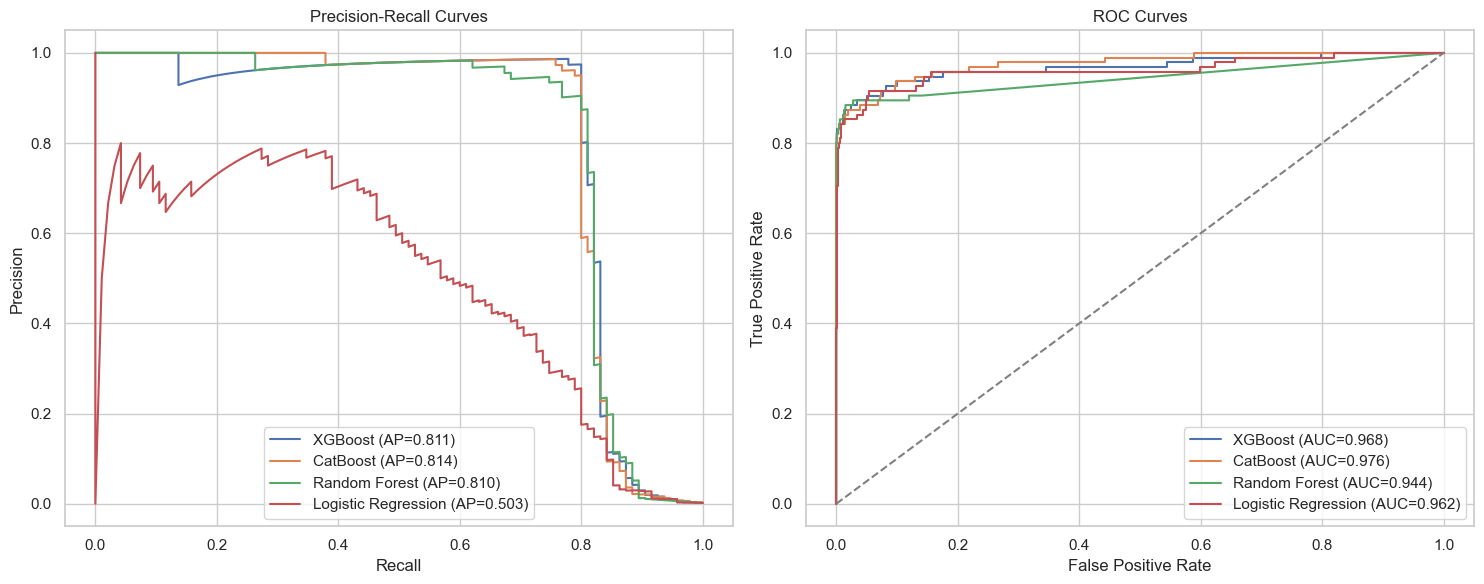

Saved plot: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\plots\05_tuned_pr_roc_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for _, row in final_results_df.iterrows():
    model_name = row['Model']
    model = final_models[model_name]
    test_proba = predict_scores(model, X_test)

    precision, recall, _ = precision_recall_curve(y_test, test_proba)
    axes[0].plot(recall, precision, label=f'{model_name} (AP={row["Test Average Precision"]:.3f})')

    fpr, tpr, _ = roc_curve(y_test, test_proba)
    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC={row["Test ROC-AUC"]:.3f})')

axes[0].set_title('Precision-Recall Curves')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()

axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
pr_roc_path = PLOTS_PATH / '05_tuned_pr_roc_curves.png'
plt.savefig(pr_roc_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved plot: {pr_roc_path}')

## 12. Confusion Matrix Heatmaps (Enhancement)

## 11. Save Tuning Summary

This report captures the model selected from validation behavior and the final test-set performance.

In [11]:
best_row = final_results_df.iloc[0]
baseline_best_line = 'No baseline comparison file found.'
if not baseline_df.empty:
    baseline_best_line = (
        f"Best baseline: {baseline_df.iloc[0]['Model']} "
        f"with ROC-AUC={baseline_df.iloc[0]['ROC-AUC']:.4f}, "
        f"Recall={baseline_df.iloc[0]['Recall']:.4f}, "
        f"F1={baseline_df.iloc[0]['F1-Score']:.4f}."
    )

summary_lines = [
    '=' * 80,
    'MODEL TUNING SUMMARY REPORT',
    '=' * 80,
    '',
    '1. INSIGHTS USED',
    '   - Extreme class imbalance: use class weighting / scale_pos_weight.',
    '   - Standard accuracy is avoided; recall, ROC-AUC, average precision, F1, and F2 are tracked.',
    '   - Preprocessing outputs are reused directly to preserve the original stratified split.',
    '   - Test set is used only for final evaluation after hyperparameters and thresholds are chosen.',
    f'   - {baseline_best_line}',
    '',
    '2. TUNING SETUP',
    f'   - Models tuned: {", ".join(TUNE_MODELS)}',
    f'   - CV folds: {CV_FOLDS}',
    f'   - Randomized search iterations per model: {N_ITER_PER_MODEL}',
    f'   - Refit score: average_precision',
    f'   - Threshold rule: maximize F2 with recall >= {MIN_RECALL_TARGET:.2f} when possible',
    '',
    '3. BEST TUNED MODEL',
    f"   - Model: {best_row['Model']}",
    f"   - Validation threshold: {best_row['Validation Threshold']:.5f}",
    f"   - Validation precision: {best_row['Validation Precision']:.4f}",
    f"   - Validation recall: {best_row['Validation Recall']:.4f}",
    f"   - Validation F2: {best_row['Validation F2']:.4f}",
    '',
    '4. FINAL TEST PERFORMANCE',
    f"   - Precision: {best_row['Test Precision @Tuned']:.4f}",
    f"   - Recall: {best_row['Test Recall @Tuned']:.4f}",
    f"   - F1: {best_row['Test F1 @Tuned']:.4f}",
    f"   - F2: {best_row['Test F2 @Tuned']:.4f}",
    f"   - ROC-AUC: {best_row['Test ROC-AUC']:.4f}",
    f"   - Average precision: {best_row['Test Average Precision']:.4f}",
    f"   - False positives: {int(best_row['Test FP @Tuned']):,}",
    f"   - False negatives: {int(best_row['Test FN @Tuned']):,}",
    f"   - True positives: {int(best_row['Test TP @Tuned']):,}",
    '',
    '5. OUTPUT FILES',
    '   - reports/tuning_cv_results.csv',
    '   - reports/tuning_results.csv',
    '   - reports/tuned_thresholds.csv',
    '   - reports/tuning_summary.txt',
    '   - models/tuned_<model>.pkl',
    '   - models/best_tuned_model.pkl',
    '   - plots/05_tuned_pr_roc_curves.png',
    '',
    '6. NEXT STEPS',
    '   - Compare tuned performance with the baseline report.',
    '   - If recall is still too low, lower the threshold or increase MIN_RECALL_TARGET.',
    '   - If false positives are too high, raise the threshold or select a model with stronger validation precision.',
    '   - Move to SHAP explainability for the selected tuned model.',
    '',
    '=' * 80,
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

summary_path = REPORTS_PATH / 'tuning_summary.txt'
summary_path.write_text(summary_text, encoding='utf-8')
print(f'Saved: {summary_path}')

MODEL TUNING SUMMARY REPORT

1. INSIGHTS USED
   - Extreme class imbalance: use class weighting / scale_pos_weight.
   - Standard accuracy is avoided; recall, ROC-AUC, average precision, F1, and F2 are tracked.
   - Preprocessing outputs are reused directly to preserve the original stratified split.
   - Test set is used only for final evaluation after hyperparameters and thresholds are chosen.
   - Best baseline: CatBoost with ROC-AUC=0.9741, Recall=0.8105, F1=0.6444.

2. TUNING SETUP
   - Models tuned: CatBoost, XGBoost, Logistic Regression, Random Forest
   - CV folds: 3
   - Randomized search iterations per model: 12
   - Refit score: average_precision
   - Threshold rule: maximize F2 with recall >= 0.80 when possible

3. BEST TUNED MODEL
   - Model: XGBoost
   - Validation threshold: 0.89896
   - Validation precision: 0.9559
   - Validation recall: 0.8553
   - Validation F2: 0.8737

4. FINAL TEST PERFORMANCE
   - Precision: 0.9867
   - Recall: 0.7789
   - F1: 0.8706
   - F2: 0.813